<a href="https://colab.research.google.com/github/pavithrahari1395-code/rfm_project/blob/main/rfm_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Jupyter Notebooks

In this chapter, we'll cover Jupyter Notebooks, including how to write and execute code and how to write text in the **Markdown** format. We'll also discuss what the kernel is, so that you understand generally how Jupyter Notebooks work.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker #ormat numbers on graph axes to make them more readable.eg100000 as-1,00,000
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')



In [ ]:
from google.colab import files
files.upload()

Saving rfm_data.csv to rfm_data.csv


{'rfm_data.csv': b'CustomerID,PurchaseDate,TransactionAmount,ProductInformation,OrderID,Location\n8814,2023-04-11,943.31,Product C,890075,Tokyo\n2188,2023-04-11,463.7,Product A,176819,London\n4608,2023-04-11,80.28,Product A,340062,New York\n2559,2023-04-11,221.29,Product A,239145,London\n9482,2023-04-11,739.56,Product A,194545,Paris\n8483,2023-04-11,375.23,Product C,691194,Paris\n8317,2023-04-11,272.56,Product B,826847,New York\n6911,2023-04-11,433.33,Product C,963918,Tokyo\n8993,2023-04-12,16.55,Product D,112426,New York\n3519,2023-04-12,464.63,Product C,139726,New York\n9005,2023-04-12,120.75,Product C,972064,Paris\n9409,2023-04-12,865.98,Product A,597126,London\n5670,2023-04-12,392.7,Product B,995296,London\n8724,2023-04-12,623.35,Product C,739717,London\n9148,2023-04-12,99.15,Product D,629996,Tokyo\n5837,2023-04-12,978.17,Product D,387813,New York\n2767,2023-04-12,299.57,Product D,342397,Tokyo\n2824,2023-04-12,744.13,Product B,334053,London\n9128,2023-04-12,388.9,Product D,281201,P

In [ ]:
#load dataset
df = pd.read_csv('rfm_data.csv')
df.head(10)


,CustomerID,PurchaseDate,TransactionAmount,ProductInformation,OrderID,Location
0,8814,2023-04-11,943.31,Product C,890075,Tokyo
1,2188,2023-04-11,463.70,Product A,176819,London
2,4608,2023-04-11,80.28,Product A,340062,New York
3,2559,2023-04-11,221.29,Product A,239145,London
4,9482,2023-04-11,739.56,Product A,194545,Paris
5,8483,2023-04-11,375.23,Product C,691194,Paris
6,8317,2023-04-11,272.56,Product B,826847,New York
7,6911,2023-04-11,433.33,Product C,963918,Tokyo
8,8993,2023-04-12,16.55,Product D,112426,New York
9,3519,2023-04-12,464.63,Product C,139726,New York


In [ ]:
print(f"rows:{df.shape[0]}, columns: {df.shape[1]}") #{} stores unique vales

rows:1000, columns: 6


In [ ]:
print(df.dtypes)

CustomerID              int64
PurchaseDate           object
TransactionAmount     float64
ProductInformation     object
OrderID                 int64
Location               object
dtype: object


In [ ]:
print (df.isnull().sum())

CustomerID            0
PurchaseDate          0
TransactionAmount     0
ProductInformation    0
OrderID               0
Location              0
dtype: int64


In [ ]:
df.columns = df.columns.str.strip()
df['PurchaseDate'] = pd.to_datetime(df['PurchaseDate'])

In [ ]:
df['TransactionAmount'] =pd.to_numeric(df['TransactionAmount'],errors='coerce')

In [ ]:
df.dropna(subset=['CustomerID','PurchaseDate','TransactionAmount'], inplace = True)# dropna remomes NAN in given subset

In [ ]:
print(df.dtypes)

CustomerID                     int64
PurchaseDate          datetime64[ns]
TransactionAmount            float64
ProductInformation            object
OrderID                        int64
Location                      object
dtype: object


In [ ]:
print(df.describe())

        CustomerID                PurchaseDate  TransactionAmount  \
count  1000.000000                        1000         1000.00000   
mean   5554.789000  2023-05-10 07:27:50.400000          513.67781   
min    1011.000000         2023-04-11 00:00:00           12.13000   
25%    3273.000000         2023-04-26 00:00:00          257.12000   
50%    5538.000000         2023-05-09 00:00:00          523.56500   
75%    7821.750000         2023-05-26 00:00:00          759.86000   
max    9991.000000         2023-06-10 00:00:00          999.44000   
std    2605.014863                         NaN          286.09870   

             OrderID  
count    1000.000000  
mean   554071.398000  
min    100096.000000  
25%    313152.000000  
50%    564671.500000  
75%    783052.250000  
max    999695.000000  
std    264695.448814  


In [ ]:
reference_date = df['PurchaseDate'].max() + pd.Timedelta(days=1) # Calculate RFM Values

In [ ]:
rfm = df.groupby('CustomerID').agg(
    Recency   = ('PurchaseDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('OrderID', 'count'),
    Monetary  = ('TransactionAmount', 'sum')
)

In [ ]:
rfm = df.groupby('CustomerID').agg({
    'PurchaseDate': lambda x: (reference_date - x.max()).days,
    'OrderID': 'count',
    'TransactionAmount': 'sum'
})

In [ ]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [ ]:
print(rfm.head(10).to_string(index=False))


 Recency  Frequency  Monetary
      34          2   1129.02
      22          1    359.29
       1          1    704.99
      44          1    859.82
      14          1    225.72
      25          1    600.69
      10          1    100.18
      35          1    146.12
      29          1    883.21
      29          1    999.44


In [ ]:
print(f"\nTotal unique customers: {len(rfm)}")



Total unique customers: 946


In [ ]:
rfm['R_score'] = pd.qcut(rfm['Recency'], q=4, labels=[4,3,2,1]) #"QUESTION 3: Assign RFM Scores (1–4 quantiles)"

In [ ]:
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1,2,3,4])


In [ ]:
rfm['M_score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1,2,3,4])

In [ ]:
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

In [ ]:
print(rfm.head(10).to_string(index=False))

 Recency  Frequency  Monetary r_score f_score m_score RFM_Score R_score F_score M_score
      34          2   1129.02       2       4       4       244       2       4       4
      22          1    359.29       3       1       2       312       3       1       2
       1          1    704.99       4       1       3       413       4       1       3
      44          1    859.82       2       1       4       214       2       1       4
      14          1    225.72       4       1       1       411       4       1       1
      25          1    600.69       3       1       3       313       3       1       3
      10          1    100.18       4       1       1       411       4       1       1
      35          1    146.12       2       1       1       211       2       1       1
      29          1    883.21       3       1       4       314       3       1       4
      29          1    999.44       3       1       4       314       3       1       4


In [ ]:
# Q4.Create RFM Segments,one row (one customer) and assign a segment name
def segment_customer(row):
  r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
  if r >= 3 and f >= 3 and m >= 3:
        return 'Champions'
  elif r >= 3 and f >= 2:
        return 'Loyal Customers'
  elif r == 4 and f <= 1:
        return 'New Customers'
  elif r >= 3 and m >= 3:
        return 'Potential Loyalists'
  elif r == 2 and f >= 2:
        return 'At Risk'
  elif r <= 2 and f <= 2 and m >= 3:
        return "Can't Lose Them"
  elif r == 1 and f >= 2:
        return 'Lost'
  else:
        return 'Hibernating'
  rfm['Segment'] = rfm.apply(segment_customer, axis=1)


In [ ]:
print(rfm.head(10).to_string(index=False))

 Recency  Frequency  Monetary r_score f_score m_score RFM_Score R_score F_score M_score
      34          2   1129.02       2       4       4       244       2       4       4
      22          1    359.29       3       1       2       312       3       1       2
       1          1    704.99       4       1       3       413       4       1       3
      44          1    859.82       2       1       4       214       2       1       4
      14          1    225.72       4       1       1       411       4       1       1
      25          1    600.69       3       1       3       313       3       1       3
      10          1    100.18       4       1       1       411       4       1       1
      35          1    146.12       2       1       1       211       2       1       1
      29          1    883.21       3       1       4       314       3       1       4
      29          1    999.44       3       1       4       314       3       1       4


In [ ]:
def segment_customer(row):
  r, f, m = row['R_score'], row['F_score'], row['M_score'] # Corrected column names
  if r >= 3 and f >= 3 and m >= 3:
        return 'Champions'
  elif r >= 3 and f >= 2:
        return 'Loyal Customers'
  elif r == 4 and f <= 1:
        return 'New Customers'
  elif r >= 3 and m >= 3:
        return 'Potential Loyalists'
  elif r == 2 and f >= 2:
        return 'At Risk'
  elif r <= 2 and f <= 2 and m >= 3:
        return "Can't Lose Them"
  elif r == 1 and f >= 2:
        return 'Lost'
  else:
        return 'Hibernating'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

seg_counts = rfm['Segment'].value_counts().sort_values(ascending=False)

In [ ]:
seg_counts = rfm['Segment'].value_counts().sort_values(ascending=False)

In [ ]:
seg_pct    = (seg_counts / seg_counts.sum() * 100).round(2)


In [ ]:
dist_df = pd.DataFrame({'Count': seg_counts, 'Percentage (%)': seg_pct})
print(dist_df.to_string())


                     Count  Percentage (%)
Segment                                   
Loyal Customers        238           25.16
At Risk                185           19.56
Lost                   135           14.27
Champions              122           12.90
Hibernating             88            9.30
Can't Lose Them         82            8.67
New Customers           60            6.34
Potential Loyalists     36            3.81


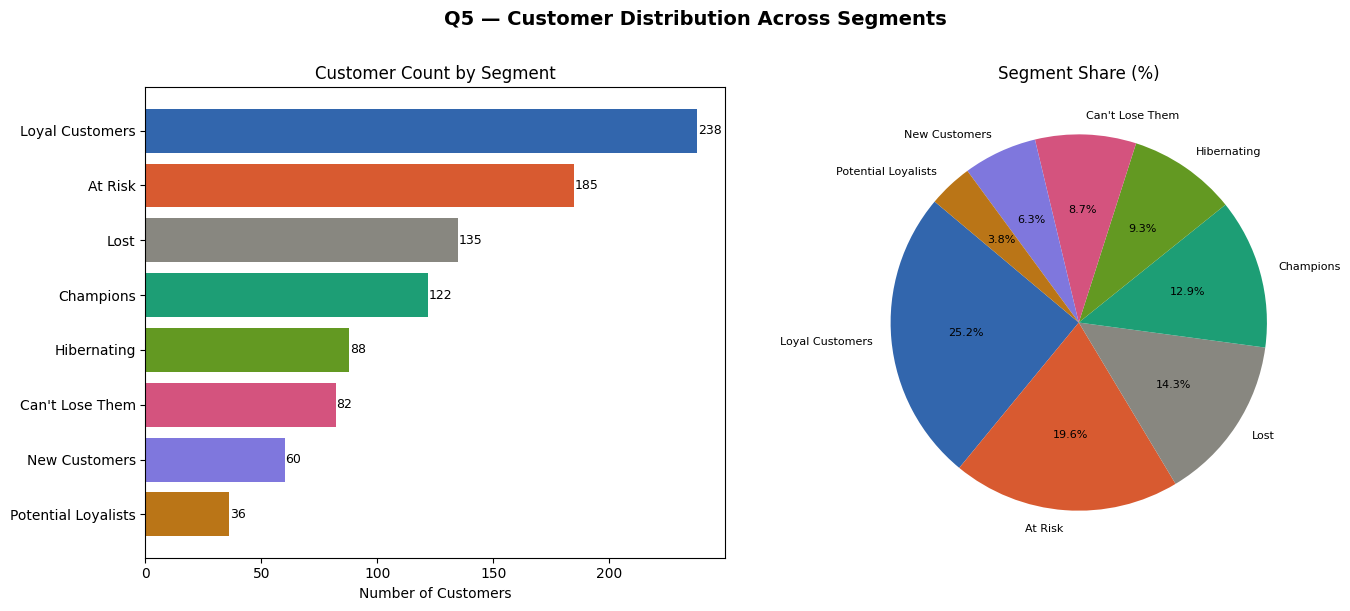

Saved: q5_customer_distribution.png


In [ ]:
palette = {
    'Champions':          '#1D9E75',
    'Loyal Customers':    '#3266ad',
    'New Customers':      '#7F77DD',
    'Potential Loyalists':'#BA7517',
    'At Risk':            '#D85A30',
    "Can't Lose Them":    '#D4537E',
    'Lost':               '#888780',
    'Hibernating':        '#639922',
}
colors = [palette.get(s, '#888780') for s in seg_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Q5 — Customer Distribution Across Segments', fontsize=14, fontweight='bold', y=1.01)

axes[0].barh(seg_counts.index[::-1], seg_counts.values[::-1], color=colors[::-1])
axes[0].set_xlabel('Number of Customers')
axes[0].set_title('Customer Count by Segment')
for i, (val, lbl) in enumerate(zip(seg_counts.values[::-1], seg_counts.index[::-1])):
    axes[0].text(val + 0.3, i, str(val), va='center', fontsize=9)

wedges, texts, autotexts = axes[1].pie(
    seg_counts.values, labels=seg_counts.index,
    colors=colors, autopct='%1.1f%%', startangle=140,
    textprops={'fontsize': 8}
)
axes[1].set_title('Segment Share (%)')

plt.tight_layout()
plt.savefig('q5_customer_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: q5_customer_distribution.png")



In [ ]:
#  Revenue Contribution by Segment
seg_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
seg_rev_pct = (seg_revenue / seg_revenue.sum() * 100).round(2)



                     Total Revenue ($)  Revenue Share (%)
Segment                                                  
Champions                    107344.39              20.90
At Risk                      104141.77              20.27
Loyal Customers               93190.44              18.14
Can't Lose Them               62878.31              12.24
Lost                          59120.09              11.51
New Customers                 31723.02               6.18
Potential Loyalists           28942.72               5.63
Hibernating                   26337.07               5.13


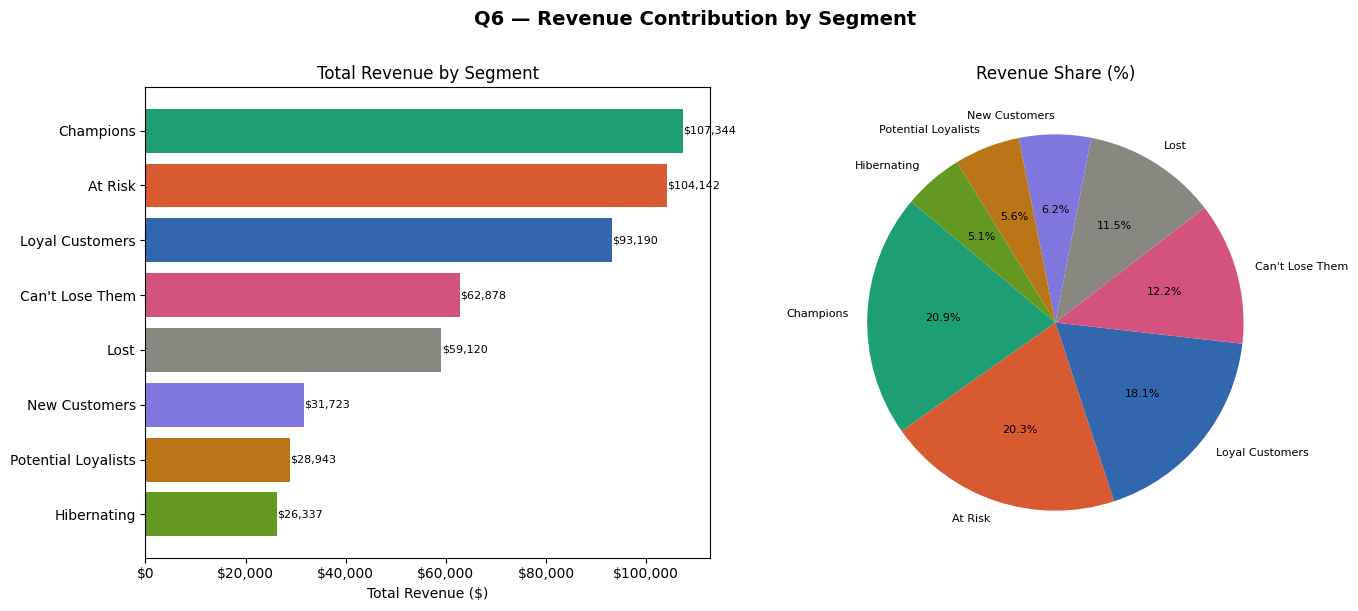

Saved: q6_revenue_contribution.png


In [ ]:
rev_df = pd.DataFrame({'Total Revenue ($)': seg_revenue.round(2), 'Revenue Share (%)': seg_rev_pct})
print(rev_df.to_string())

rev_colors = [palette.get(s, '#888780') for s in seg_revenue.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Q6 — Revenue Contribution by Segment', fontsize=14, fontweight='bold', y=1.01)

axes[0].barh(seg_revenue.index[::-1], seg_revenue.values[::-1], color=rev_colors[::-1])
axes[0].set_xlabel('Total Revenue ($)')
axes[0].set_title('Total Revenue by Segment')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for i, val in enumerate(seg_revenue.values[::-1]):
    axes[0].text(val + 50, i, f'${val:,.0f}', va='center', fontsize=8)

wedges, texts, autotexts = axes[1].pie(
    seg_revenue.values, labels=seg_revenue.index,
    colors=rev_colors, autopct='%1.1f%%', startangle=140,
    textprops={'fontsize': 8}
)
axes[1].set_title('Revenue Share (%)')

plt.tight_layout()
plt.savefig('q6_revenue_contribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: q6_revenue_contribution.png")



count    946.00
mean      30.98
std       17.32
min        1.00
25%       15.00
50%       32.00
75%       45.00
max       61.00


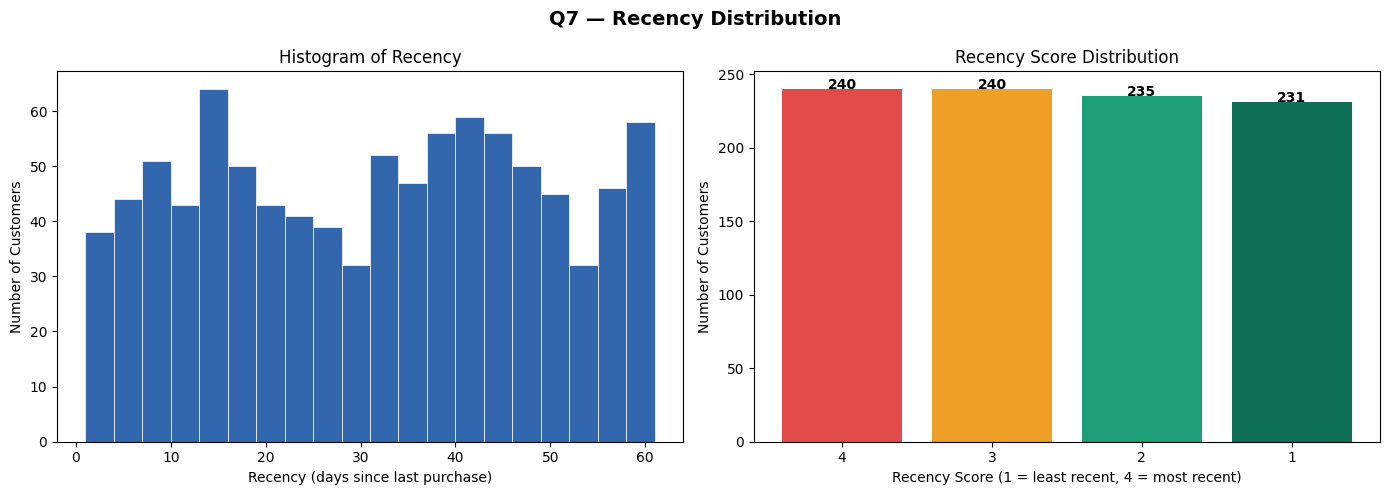

Saved: q7_recency_distribution.png


In [ ]:
# Recency Distribution
print(rfm['Recency'].describe().round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Q7 — Recency Distribution', fontsize=14, fontweight='bold')

axes[0].hist(rfm['Recency'], bins=20, color='#3266ad', edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Recency (days since last purchase)')
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Histogram of Recency')

score_counts = rfm['R_score'].value_counts().sort_index()
score_colors = ['#E24B4A', '#EF9F27', '#1D9E75', '#0F6E56']
axes[1].bar(score_counts.index.astype(str), score_counts.values, color=score_colors)
axes[1].set_xlabel('Recency Score (1 = least recent, 4 = most recent)')
axes[1].set_ylabel('Number of Customers')
axes[1].set_title('Recency Score Distribution')
for i, val in enumerate(score_counts.values):
    axes[1].text(i, val + 0.3, str(val), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('q7_recency_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: q7_recency_distribution.png")

count    946.00
mean       1.06
std        0.25
min        1.00
25%        1.00
50%        1.00
75%        1.00
max        3.00


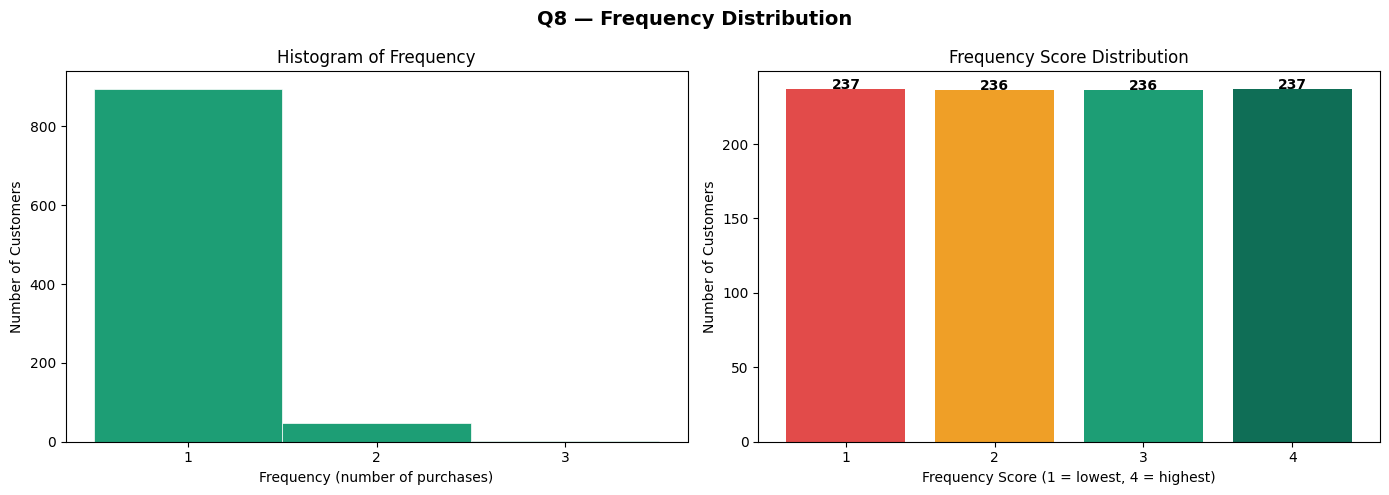

Saved: q8_frequency_distribution.png


In [ ]:
# Frequency Distribution
print(rfm['Frequency'].describe().round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Q8 — Frequency Distribution', fontsize=14, fontweight='bold')

axes[0].hist(rfm['Frequency'], bins=range(1, rfm['Frequency'].max() + 2),
             color='#1D9E75', edgecolor='white', linewidth=0.5, align='left')
axes[0].set_xlabel('Frequency (number of purchases)')
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Histogram of Frequency')
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

f_score_counts = rfm['F_score'].value_counts().sort_index()
axes[1].bar(f_score_counts.index.astype(str), f_score_counts.values, color=score_colors)
axes[1].set_xlabel('Frequency Score (1 = lowest, 4 = highest)')
axes[1].set_ylabel('Number of Customers')
axes[1].set_title('Frequency Score Distribution')
for i, val in enumerate(f_score_counts.values):
    axes[1].text(i, val + 0.3, str(val), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('q8_frequency_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: q8_frequency_distribution.png")

count     946.00
mean      543.00
std       324.38
min        12.13
25%       266.64
50%       542.90
75%       782.70
max      2379.45


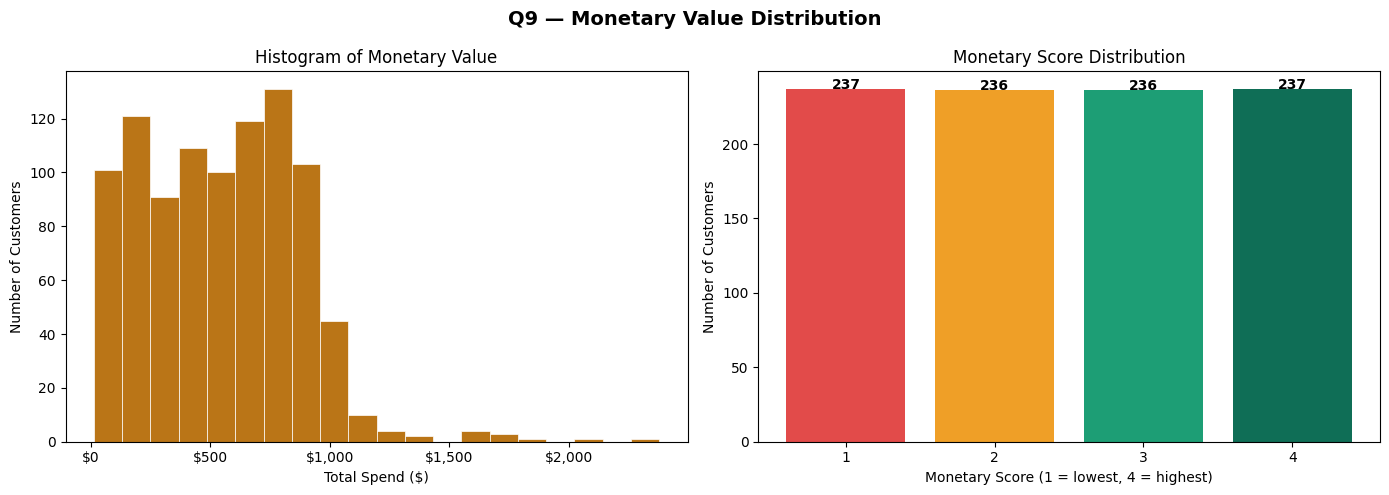

Saved: q9_monetary_distribution.png


In [ ]:
#Monetary Value Distribution
print(rfm['Monetary'].describe().round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Q9 — Monetary Value Distribution', fontsize=14, fontweight='bold')

axes[0].hist(rfm['Monetary'], bins=20, color='#BA7517', edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Total Spend ($)')
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Histogram of Monetary Value')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

m_score_counts = rfm['M_score'].value_counts().sort_index()
axes[1].bar(m_score_counts.index.astype(str), m_score_counts.values, color=score_colors)
axes[1].set_xlabel('Monetary Score (1 = lowest, 4 = highest)')
axes[1].set_ylabel('Number of Customers')
axes[1].set_title('Monetary Score Distribution')
for i, val in enumerate(m_score_counts.values):
    axes[1].text(i, val + 0.3, str(val), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('q9_monetary_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: q9_monetary_distribution.png")


--- Top Segments Summary Table ---
            Segment  Customer_Count  Total_Revenue  Avg_Monetary  Avg_Recency  Avg_Frequency  Revenue_Share_%  Customer_Share_%
    Loyal Customers             238       93190.44        391.56         15.8           1.02            18.14             25.16
            At Risk             185      104141.77        562.93         39.1           1.08            20.27             19.56
               Lost             135       59120.09        437.93         53.5           1.02            11.51             14.27
          Champions             122      107344.39        879.87         16.6           1.25            20.90             12.90
        Hibernating              88       26337.07        299.28         41.2           1.00             5.13              9.30
    Can't Lose Them              82       62878.31        766.81         49.5           1.00            12.24              8.67
      New Customers              60       31723.02        528.72    

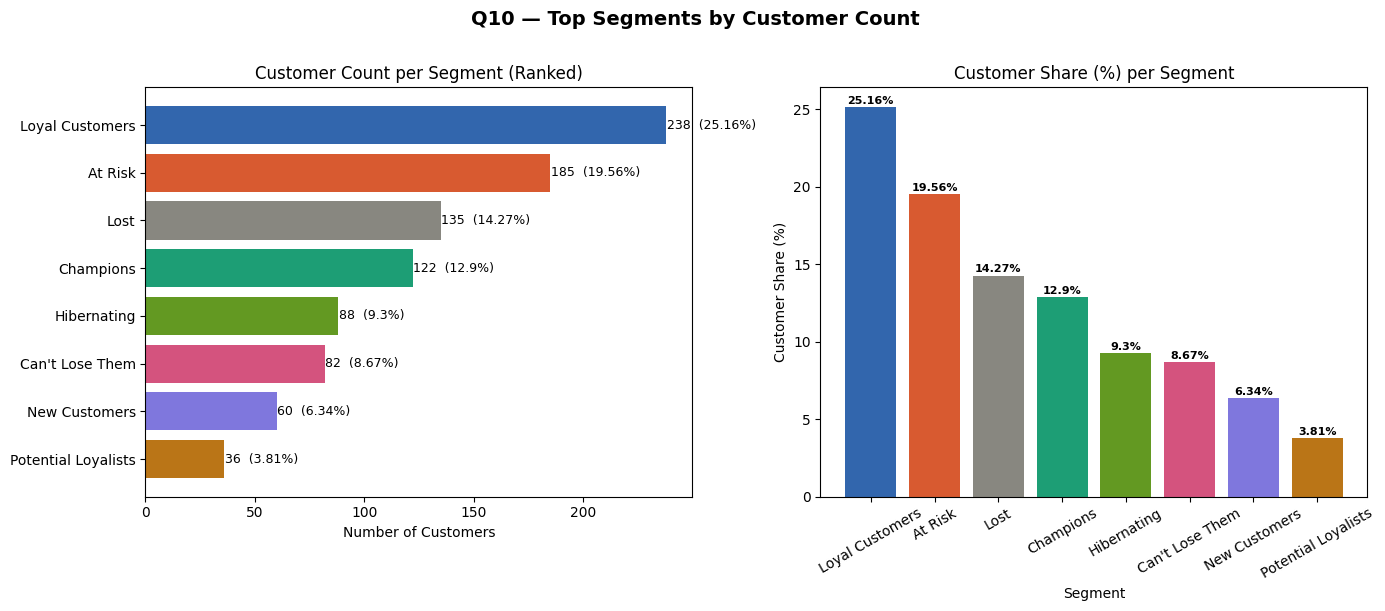

Saved: q10_top_segments.png

ALL 10 STEPS COMPLETE

Final RFM table shape: (946, 11)
Columns: ['Recency', 'Frequency', 'Monetary', 'r_score', 'f_score', 'm_score', 'RFM_Score', 'R_score', 'F_score', 'M_score', 'Segment']

--- Full RFM Table Sample (10 rows) ---
 Recency  Frequency  Monetary r_score f_score m_score RFM_Score R_score F_score M_score         Segment
      38          1    681.52       2       2       3       223       2       2       3         At Risk
      40          1    819.21       2       1       4       214       2       1       4 Can't Lose Them
      37          1     14.62       2       4       1       241       2       4       1         At Risk
       7          1    964.36       4       2       4       424       4       2       4 Loyal Customers
      55          1    815.05       1       1       4       114       1       1       4 Can't Lose Them
      55          1    582.90       1       3       3       133       1       3       3            Lost
      43  

In [ ]:
#Top Segments by Customer Count
top_segments = rfm.reset_index().groupby('Segment').agg(
    Customer_Count = ('CustomerID', 'count'),
    Total_Revenue  = ('Monetary',   'sum'),
    Avg_Monetary   = ('Monetary',   'mean'),
    Avg_Recency    = ('Recency',    'mean'),
    Avg_Frequency  = ('Frequency',  'mean')
).sort_values('Customer_Count', ascending=False).reset_index()

top_segments['Revenue_Share_%']  = (top_segments['Total_Revenue']  / top_segments['Total_Revenue'].sum()  * 100).round(2)
top_segments['Customer_Share_%'] = (top_segments['Customer_Count'] / top_segments['Customer_Count'].sum() * 100).round(2)
top_segments['Total_Revenue']    = top_segments['Total_Revenue'].round(2)
top_segments['Avg_Monetary']     = top_segments['Avg_Monetary'].round(2)
top_segments['Avg_Recency']      = top_segments['Avg_Recency'].round(1)
top_segments['Avg_Frequency']    = top_segments['Avg_Frequency'].round(2)

print("\n--- Top Segments Summary Table ---")
print(top_segments.to_string(index=False))

top_colors = [palette.get(s, '#888780') for s in top_segments['Segment']]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Q10 — Top Segments by Customer Count', fontsize=14, fontweight='bold', y=1.01)

bars = axes[0].barh(top_segments['Segment'][::-1],
                    top_segments['Customer_Count'][::-1],
                    color=top_colors[::-1])
axes[0].set_xlabel('Number of Customers')
axes[0].set_title('Customer Count per Segment (Ranked)')
for i, (cnt, share) in enumerate(zip(top_segments['Customer_Count'][::-1],
                                      top_segments['Customer_Share_%'][::-1])):
    axes[0].text(cnt + 0.2, i, f'{cnt}  ({share}%)', va='center', fontsize=9)

axes[1].bar(top_segments['Segment'],
            top_segments['Customer_Share_%'],
            color=top_colors)
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Customer Share (%)')
axes[1].set_title('Customer Share (%) per Segment')
axes[1].tick_params(axis='x', rotation=30)
for i, val in enumerate(top_segments['Customer_Share_%']):
    axes[1].text(i, val + 0.2, f'{val}%', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('q10_top_segments.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: q10_top_segments.png")

print("\n" + "=" * 55)
print("ALL 10 STEPS COMPLETE")
print("=" * 55)
print(f"\nFinal RFM table shape: {rfm.shape}")
print(f"Columns: {list(rfm.columns)}")
print("\n--- Full RFM Table Sample (10 rows) ---")
print(rfm.sample(10, random_state=42).to_string(index=False))

In [ ]:
df_seg = df.merge(rfm.reset_index()[['CustomerID', 'Segment', 'R_score', 'F_score', 'M_score',
                         'Recency', 'Frequency', 'Monetary']], on='CustomerID', how='left')

PALETTE = {
    'Champions':          '#1D9E75',
    'Loyal Customers':    '#3266ad',
    'New Customers':      '#7F77DD',
    'Potential Loyalists':'#BA7517',
    'At Risk':            '#D85A30',
    "Can't Lose Them":    '#D4537E',
    'Lost':               '#888780',
    'Hibernating':        '#639922',
}

def seg_color(seg): return PALETTE.get(seg, '#888780')

plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': '#fafafa',
                     'axes.grid': True, 'grid.alpha': 0.35,
                     'font.family': 'DejaVu Sans', 'axes.spines.top': False,
                     'axes.spines.right': False})



Total customers flagged as churn-risk: 490
As % of customer base: 51.8%

--- Churn-Risk Segment Summary ---
                 Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  Total_Revenue
Segment                                                                            
At Risk                185        39.11           1.08        562.93      104141.77
Can't Lose Them         82        49.55           1.00        766.81       62878.31
Lost                   135        53.51           1.02        437.93       59120.09
Hibernating             88        41.20           1.00        299.28       26337.07

--- Top 10 Highest Churn-Risk Customers ---
 CustomerID     Segment  Recency  Frequency  Monetary  Churn_Score
       1520 Hibernating       60          1    102.76          4.0
       1742 Hibernating       59          1    145.67          4.0
       3308 Hibernating       55          1     60.10          4.0
       1464 Hibernating       56          1     55.01          4.0
       

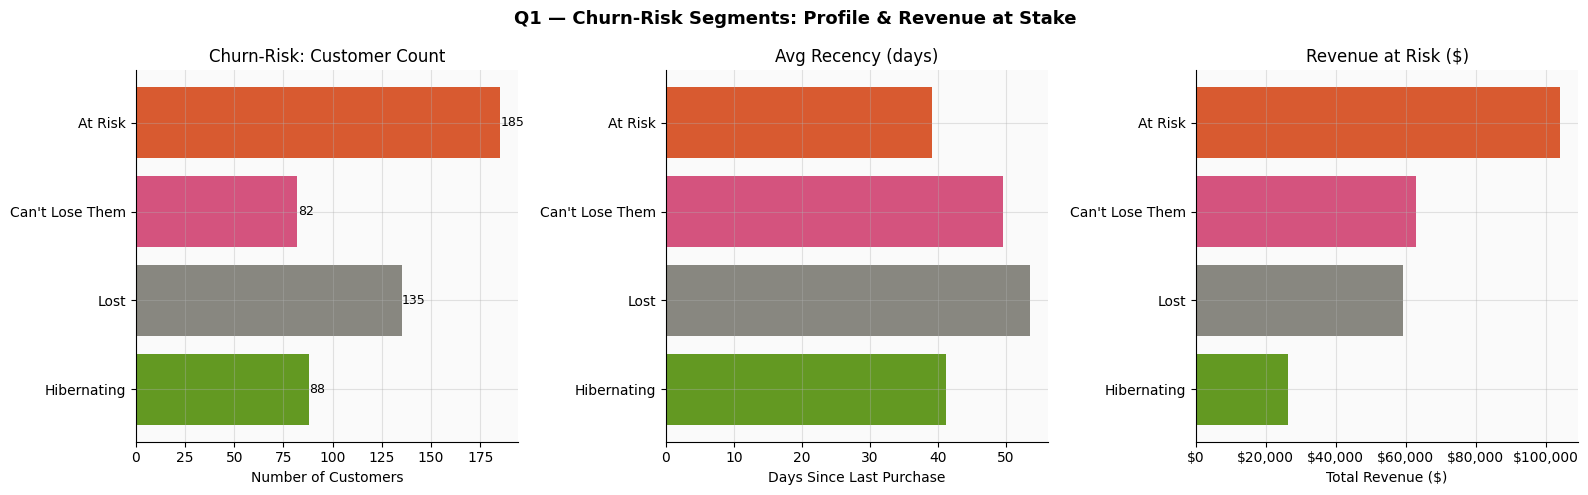

Saved: q1_churn_risk.png


In [ ]:
# QUESTION 1 — Churn-Risk Identification & Retention Interventions
CHURN_SEGMENTS = ['At Risk', 'Hibernating', 'Lost', "Can't Lose Them"]
churn_df = rfm[rfm['Segment'].isin(CHURN_SEGMENTS)].copy().reset_index()

print(f"\nTotal customers flagged as churn-risk: {len(churn_df):,}")
print(f"As % of customer base: {len(churn_df)/len(rfm)*100:.1f}%\n")

churn_summary = churn_df.groupby('Segment').agg(
    Customers     = ('CustomerID', 'count'),
    Avg_Recency   = ('Recency',    'mean'),
    Avg_Frequency = ('Frequency',  'mean'),
    Avg_Monetary  = ('Monetary',   'mean'),
    Total_Revenue = ('Monetary',   'sum')
).round(2).sort_values('Total_Revenue', ascending=False)

print("--- Churn-Risk Segment Summary ---")
print(churn_summary.to_string())

# Ensure score columns are numeric for arithmetic operations
rfm['R_score'] = rfm['R_score'].astype(int)
rfm['F_score'] = rfm['F_score'].astype(int)
rfm['M_score'] = rfm['M_score'].astype(int)
churn_df['R_score'] = churn_df['R_score'].astype(int)
churn_df['F_score'] = churn_df['F_score'].astype(int)
churn_df['M_score'] = churn_df['M_score'].astype(int)

# Churn score: composite risk index (high recency + low F + low M)
churn_df['Churn_Score'] = (
    (rfm['R_score'].max() + 1 - churn_df['R_score']) * 0.5 +
    (rfm['F_score'].max() + 1 - churn_df['F_score']) * 0.3 +
    (rfm['M_score'].max() + 1 - churn_df['M_score']) * 0.2
)
print("\n--- Top 10 Highest Churn-Risk Customers ---")
print(churn_df.sort_values('Churn_Score', ascending=False)
      [['CustomerID','Segment','Recency','Frequency','Monetary','Churn_Score']]
      .head(10).to_string(index=False))

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Q1 — Churn-Risk Segments: Profile & Revenue at Stake', fontsize=13, fontweight='bold')

colors_q1 = [seg_color(s) for s in churn_summary.index]
axes[0].barh(churn_summary.index[::-1], churn_summary['Customers'][::-1], color=colors_q1[::-1])
axes[0].set_xlabel('Number of Customers')
axes[0].set_title('Churn-Risk: Customer Count')
for i, v in enumerate(churn_summary['Customers'][::-1]):
    axes[0].text(v + 0.2, i, str(v), va='center', fontsize=9)

axes[1].barh(churn_summary.index[::-1], churn_summary['Avg_Recency'][::-1], color=colors_q1[::-1])
axes[1].set_xlabel('Days Since Last Purchase')
axes[1].set_title('Avg Recency (days)')

axes[2].barh(churn_summary.index[::-1], churn_summary['Total_Revenue'][::-1], color=colors_q1[::-1])
axes[2].set_xlabel('Total Revenue ($)')
axes[2].set_title('Revenue at Risk ($)')
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('q1_churn_risk.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: q1_churn_risk.png")


Segment                Strategy                      Customers  Avg Spend Tactics
--------------------------------------------------------------------------------------------------------------
Champions              Exclusivity & Advocacy              122 $      880   Early access, loyalty VIP tier, referral rewards, co-creation invites
Loyal Customers        Retention & Upsell                  238 $      392   Premium membership perks, spend-threshold bonuses, personalised bundles
New Customers          Onboarding & Habit Build             60 $      529   Welcome series emails, first-repeat-purchase incentive (+10 % off), tutorial content
Potential Loyalists    Conversion to Loyal                  36 $      804   Product education, loyalty-points intro, social-proof (reviews & ratings)
At Risk                Re-engagement                       185 $      563   Personalised "we miss you" campaign, time-sensitive 20 % discount
Can't Lose Them        High-Value Win-back                 

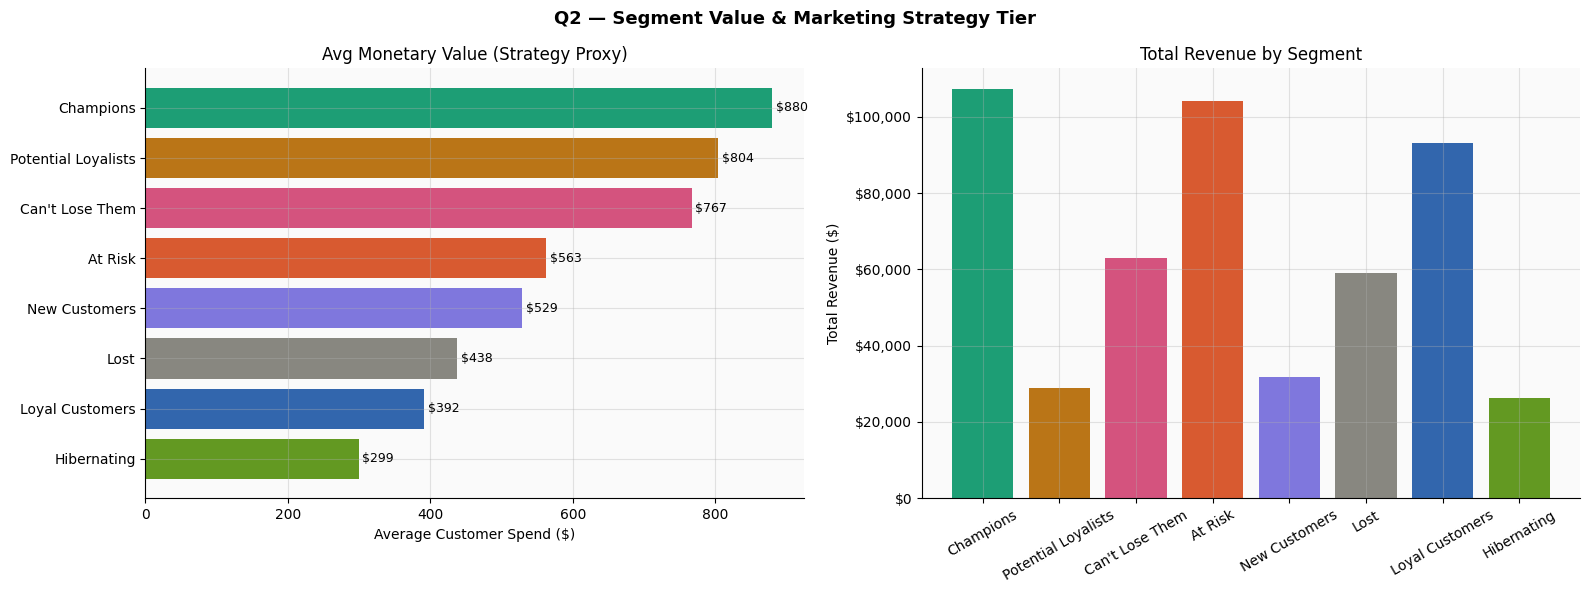

Saved: q2_marketing_strategy.png


In [ ]:
# QUESTION 2 — Marketing Strategies by Segment
strategies = {
    'Champions':           ('Exclusivity & Advocacy',   'Early access, loyalty VIP tier, referral rewards, co-creation invites'),
    'Loyal Customers':     ('Retention & Upsell',        'Premium membership perks, spend-threshold bonuses, personalised bundles'),
    'New Customers':       ('Onboarding & Habit Build',  'Welcome series emails, first-repeat-purchase incentive (+10 % off), tutorial content'),
    'Potential Loyalists': ('Conversion to Loyal',       'Product education, loyalty-points intro, social-proof (reviews & ratings)'),
    'At Risk':             ('Re-engagement',             'Personalised "we miss you" campaign, time-sensitive 20 % discount'),
    "Can't Lose Them":     ('High-Value Win-back',       'Dedicated account manager outreach, VIP exclusive bundle, survey for friction points'),
    'Lost':                ('Last-Chance Reactivation',  '30 %+ discount code, limited-window offer, unsubscribe prevention campaign'),
    'Hibernating':         ('Gentle Nudge',              'Low-cost email drip, seasonal re-engagement, social retargeting'),
}

seg_stats = rfm.reset_index().groupby('Segment').agg(
    Customers = ('CustomerID', 'count'),
    Avg_M     = ('Monetary',   'mean'),
    Total_M   = ('Monetary',   'sum'),
).round(2)

print(f"\n{'Segment':<22} {'Strategy':<28} {'Customers':>10} {'Avg Spend':>10} {'Tactics'}")
print("-" * 110)
for seg, (strat, tactics) in strategies.items():
    row = seg_stats.loc[seg] if seg in seg_stats.index else pd.Series({'Customers': 0, 'Avg_M': 0})
    print(f"{seg:<22} {strat:<28} {int(row['Customers']):>10} ${row['Avg_M']:>9.0f}   {tactics}")

# --- Plot: avg monetary by segment with strategy tier ---
seg_stats_sorted = seg_stats.sort_values('Avg_M', ascending=False)
colors_q2 = [seg_color(s) for s in seg_stats_sorted.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Q2 — Segment Value & Marketing Strategy Tier', fontsize=13, fontweight='bold')

axes[0].barh(seg_stats_sorted.index[::-1],
                    seg_stats_sorted['Avg_M'][::-1],
                    color=colors_q2[::-1])
axes[0].set_xlabel('Average Customer Spend ($)')
axes[0].set_title('Avg Monetary Value (Strategy Proxy)')
for i, v in enumerate(seg_stats_sorted['Avg_M'][::-1]):
    axes[0].text(v + 5, i, f'${v:,.0f}', va='center', fontsize=9)

axes[1].bar(seg_stats_sorted.index,
            seg_stats_sorted['Total_M'],
            color=colors_q2)
axes[1].set_ylabel('Total Revenue ($)')
axes[1].set_title('Total Revenue by Segment')
axes[1].tick_params(axis='x', rotation=30)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('q2_marketing_strategy.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: q2_marketing_strategy.png")


--- Transaction Count by Segment × Product ---
ProductInformation   Product A  Product B  Product C  Product D
Segment                                                        
At Risk                     52         50         49         49
Can't Lose Them             14         21         23         24
Champions                   30         38         47         38
Hibernating                 19         12         35         22
Lost                        33         33         39         33
Loyal Customers             50         62         64         67
New Customers               14         20         12         14
Potential Loyalists         13          9          8          6

--- Revenue by Segment × Product ---
ProductInformation   Product A  Product B  Product C  Product D
Segment                                                        
At Risk               25100.68   24477.93   27492.37   27070.79
Can't Lose Them       10707.01   16616.03   17203.34   18351.93
Champions         

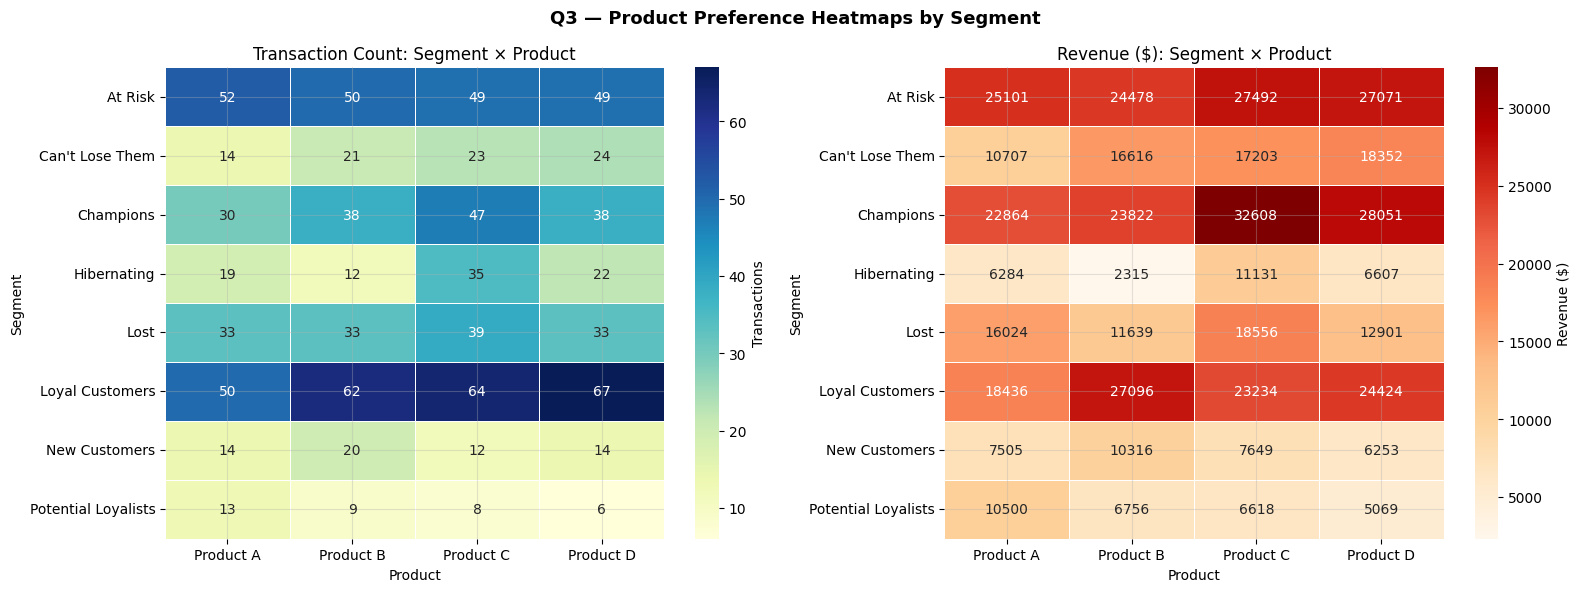

Saved: q3_product_preferences.png


In [ ]:
# QUESTION 3 — Product Preferences by Segment → Product Development
prod_seg = df_seg.groupby(['Segment', 'ProductInformation']).agg(
    Transactions = ('OrderID',           'count'),
    Revenue      = ('TransactionAmount', 'sum')
).reset_index()

pivot_txn = prod_seg.pivot_table(index='Segment', columns='ProductInformation',
                                  values='Transactions', aggfunc='sum', fill_value=0)
pivot_rev = prod_seg.pivot_table(index='Segment', columns='ProductInformation',
                                  values='Revenue', aggfunc='sum', fill_value=0)

print("\n--- Transaction Count by Segment × Product ---")
print(pivot_txn.to_string())

print("\n--- Revenue by Segment × Product ---")
print(pivot_rev.round(2).to_string())

top_products = prod_seg.groupby('ProductInformation')['Revenue'].sum().sort_values(ascending=False)
print(f"\n--- Overall Product Revenue Ranking ---")
for p, r in top_products.items():
    print(f"  {p}: ${r:,.2f}")

# --- Plot: heatmaps ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Q3 — Product Preference Heatmaps by Segment', fontsize=13, fontweight='bold')

sns.heatmap(pivot_txn, annot=True, fmt='d', cmap='YlGnBu', ax=axes[0],
            linewidths=0.5, cbar_kws={'label': 'Transactions'})
axes[0].set_title('Transaction Count: Segment × Product')
axes[0].set_xlabel('Product')
axes[0].set_ylabel('Segment')

sns.heatmap(pivot_rev.round(0).astype(int), annot=True, fmt='d', cmap='OrRd', ax=axes[1],
            linewidths=0.5, cbar_kws={'label': 'Revenue ($)'})
axes[1].set_title('Revenue ($): Segment × Product')
axes[1].set_xlabel('Product')
axes[1].set_ylabel('Segment')

plt.tight_layout()
plt.savefig('q3_product_preferences.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: q3_product_preferences.png")




--- Geographic Performance Summary ---
          Total_Revenue  Transactions  Unique_Cust  Avg_Order
Location                                                     
Tokyo         139336.06           278          270     501.21
New York      132102.79           247          244     534.83
London        129797.90           246          244     527.63
Paris         112441.06           229          228     491.01

High-Value Regions: ['Tokyo', 'New York']
Low-Engagement Regions: ['Tokyo', 'Paris']


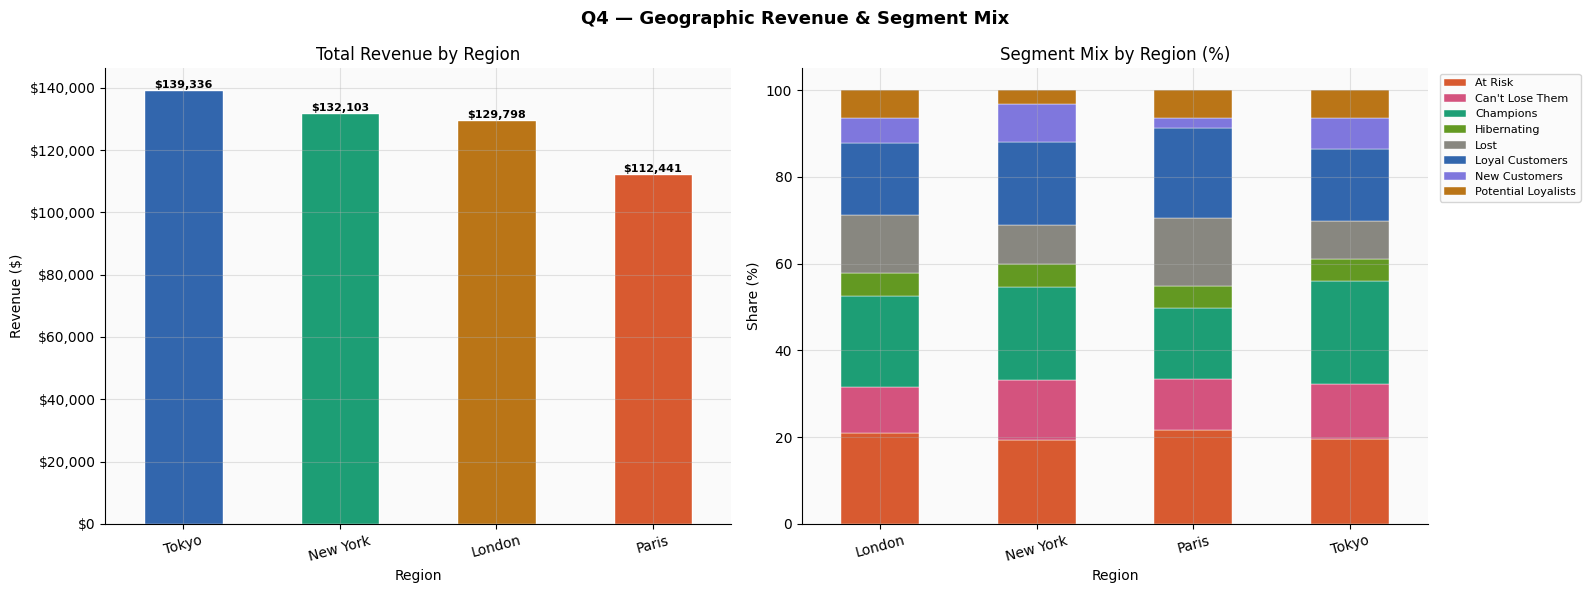

Saved: q4_geographic_targeting.png


In [ ]:
# QUESTION 4 — Geographic Targeting

geo_seg = df_seg.groupby(['Location', 'Segment']).agg(
    Transactions = ('OrderID',           'count'),
    Revenue      = ('TransactionAmount', 'sum'),
    Customers    = ('CustomerID',        'nunique')
).reset_index()

geo_summary = df_seg.groupby('Location').agg(
    Total_Revenue  = ('TransactionAmount', 'sum'),
    Transactions   = ('OrderID',           'count'),
    Unique_Cust    = ('CustomerID',        'nunique'),
    Avg_Order      = ('TransactionAmount', 'mean')
).round(2).sort_values('Total_Revenue', ascending=False)

print("\n--- Geographic Performance Summary ---")
print(geo_summary.to_string())

high_value_regions = geo_summary[geo_summary['Total_Revenue'] >= geo_summary['Total_Revenue'].quantile(0.6)]
low_engage_regions = geo_summary[geo_summary['Avg_Order'] <= geo_summary['Avg_Order'].quantile(0.4)]
print(f"\nHigh-Value Regions: {list(high_value_regions.index)}")
print(f"Low-Engagement Regions: {list(low_engage_regions.index)}")

pivot_geo = geo_seg.pivot_table(index='Location', columns='Segment',
                                 values='Revenue', aggfunc='sum', fill_value=0)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Q4 — Geographic Revenue & Segment Mix', fontsize=13, fontweight='bold')

geo_colors = ['#3266ad','#1D9E75','#BA7517','#D85A30']
geo_summary['Total_Revenue'].plot(kind='bar', ax=axes[0], color=geo_colors[:len(geo_summary)],
                                   edgecolor='white')
axes[0].set_title('Total Revenue by Region')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Revenue ($)')
axes[0].tick_params(axis='x', rotation=15)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for i, v in enumerate(geo_summary['Total_Revenue']):
    axes[0].text(i, v + 500, f'${v:,.0f}', ha='center', fontsize=8, fontweight='bold')

pivot_geo_pct = pivot_geo.div(pivot_geo.sum(axis=1), axis=0) * 100
seg_colors_list = [seg_color(c) for c in pivot_geo_pct.columns]
pivot_geo_pct.plot(kind='bar', stacked=True, ax=axes[1],
                   color=seg_colors_list, edgecolor='white', linewidth=0.3)
axes[1].set_title('Segment Mix by Region (%)')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Share (%)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('q4_geographic_targeting.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: q4_geographic_targeting.png")




--- Monthly Revenue Summary ---
MonthName   Revenue  Transactions
    April 172201.88           341
      May 267394.15           515
     June  74081.78           144


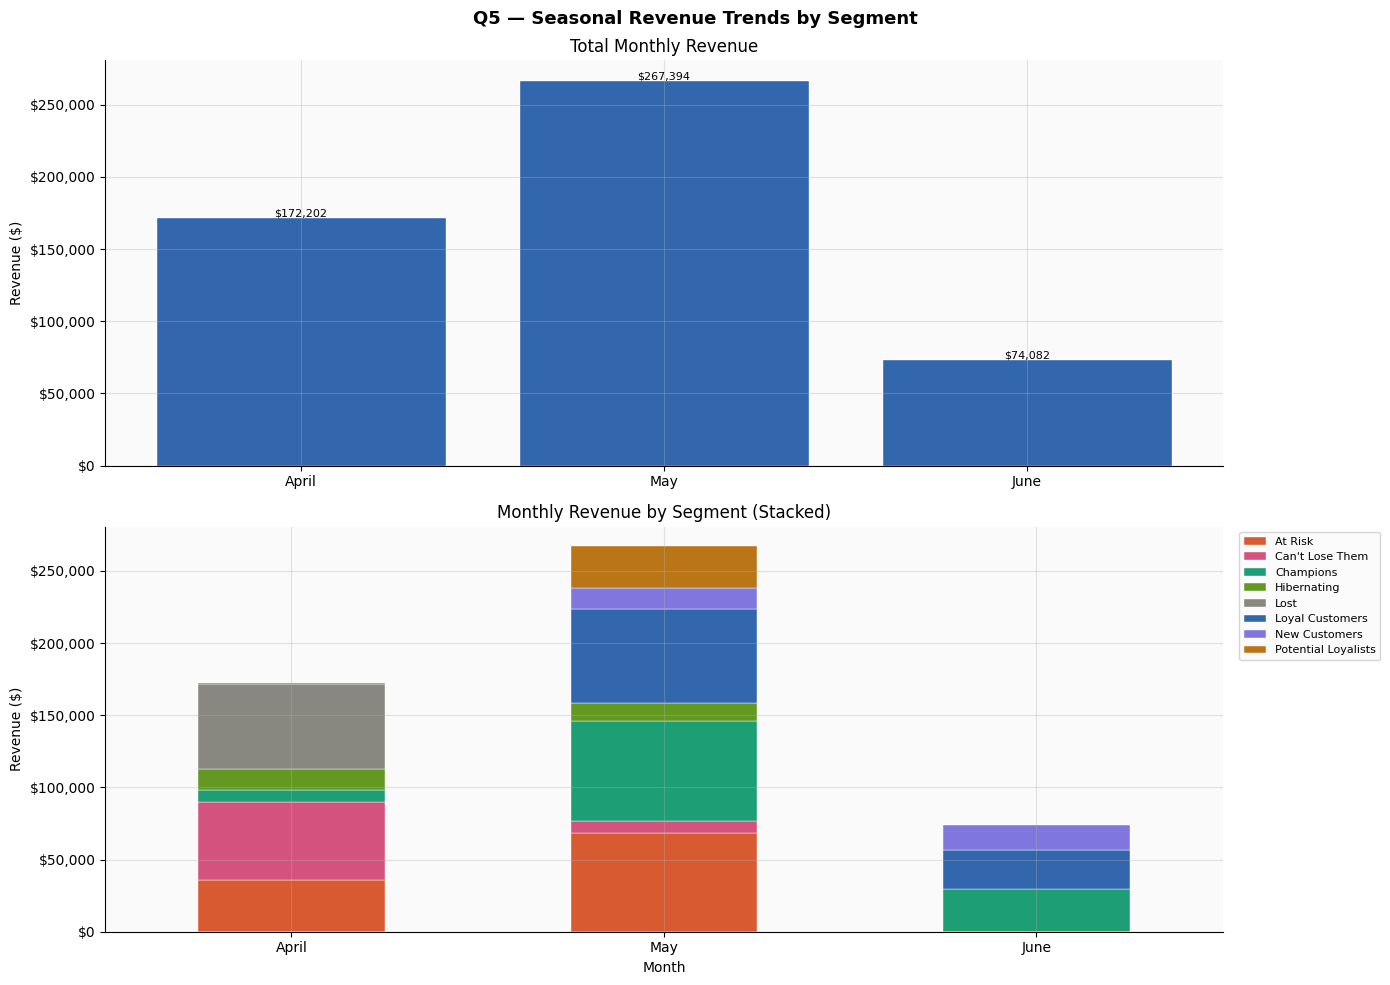

Saved: q5_seasonal_trends.png


In [ ]:
# QUESTION 5 — Seasonal Marketing Campaigns
df_seg['Month'] = df_seg['PurchaseDate'].dt.month
df_seg['MonthName'] = df_seg['PurchaseDate'].dt.month_name()

monthly_seg = df_seg.groupby(['MonthName', 'Month', 'Segment']).agg(
    Revenue      = ('TransactionAmount', 'sum'),
    Transactions = ('OrderID',           'count')
).reset_index().sort_values('Month')

monthly_total = df_seg.groupby(['MonthName', 'Month']).agg(
    Revenue      = ('TransactionAmount', 'sum'),
    Transactions = ('OrderID',           'count')
).reset_index().sort_values('Month')

print("\n--- Monthly Revenue Summary ---")
print(monthly_total[['MonthName', 'Revenue', 'Transactions']].to_string(index=False))

pivot_monthly = monthly_seg.pivot_table(index='MonthName', columns='Segment',
                                         values='Revenue', aggfunc='sum', fill_value=0)
month_order = monthly_total.sort_values('Month')['MonthName'].tolist()
pivot_monthly = pivot_monthly.reindex(month_order)

# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Q5 — Seasonal Revenue Trends by Segment', fontsize=13, fontweight='bold')

monthly_total_sorted = monthly_total.sort_values('Month')
axes[0].bar(monthly_total_sorted['MonthName'], monthly_total_sorted['Revenue'],
            color='#3266ad', edgecolor='white')
axes[0].set_title('Total Monthly Revenue')
axes[0].set_ylabel('Revenue ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for i, (_, row) in enumerate(monthly_total_sorted.iterrows()):
    axes[0].text(i, row['Revenue'] + 300, f'${row["Revenue"]:,.0f}', ha='center', fontsize=8)

seg_cols = [seg_color(c) for c in pivot_monthly.columns]
pivot_monthly.plot(kind='bar', stacked=True, ax=axes[1],
                   color=seg_cols, edgecolor='white', linewidth=0.3)
axes[1].set_title('Monthly Revenue by Segment (Stacked)')
axes[1].set_ylabel('Revenue ($)')
axes[1].set_xlabel('Month')
axes[1].tick_params(axis='x', rotation=0)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('q5_seasonal_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: q5_seasonal_trends.png")


--- Product Co-Purchase Matrix (customer overlap count) ---
ProductInformation  Product A  Product B  Product C  Product D
ProductInformation                                            
Product A                   0          5         10          7
Product B                   5          0          9          7
Product C                  10          9          0          4
Product D                   7          7          4          0

--- Cross-Sell Rate by Segment ---
                     Avg_Products_per_Cust  Max  Min
Segment                                             
Champions                             1.20    3    1
At Risk                               1.05    2    1
Loyal Customers                       1.02    2    1
Lost                                  1.02    2    1
Hibernating                           1.00    1    1
Can't Lose Them                       1.00    1    1
New Customers                         1.00    1    1
Potential Loyalists                   1.00    1 

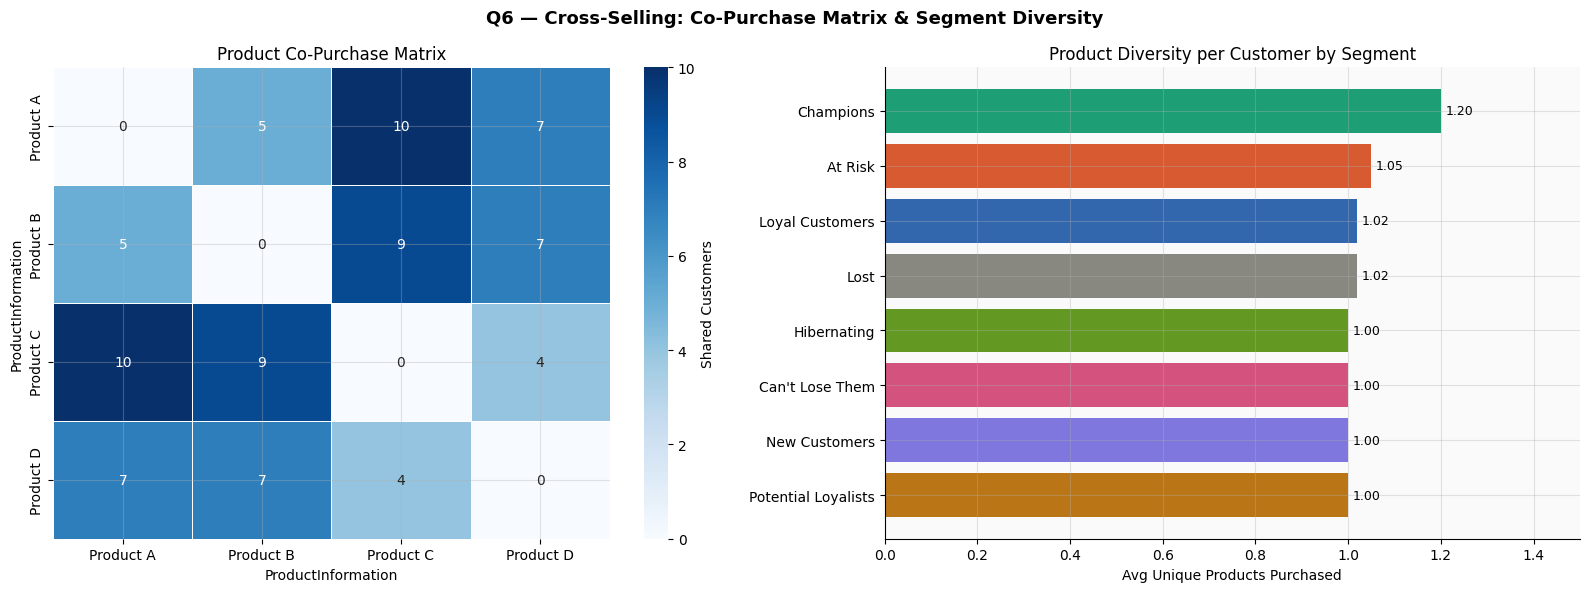

Saved: q6_cross_selling.png


In [ ]:
# QUESTION 6 — Cross-Selling Opportunities & Bundle Offers
cust_products = df.groupby(['CustomerID', 'ProductInformation']).size().unstack(fill_value=0)
cust_products_binary = (cust_products > 0).astype(int)

co_purchase = cust_products_binary.T.dot(cust_products_binary)
np.fill_diagonal(co_purchase.values, 0)

print("\n--- Product Co-Purchase Matrix (customer overlap count) ---")
print(co_purchase.to_string())

# Cross-sell rate per segment
seg_product = df_seg.groupby(['CustomerID', 'Segment'])['ProductInformation'].nunique().reset_index()
seg_product.columns = ['CustomerID', 'Segment', 'Unique_Products']

cross_sell_rate = seg_product.groupby('Segment')['Unique_Products'].agg(['mean', 'max', 'min']).round(2)
cross_sell_rate.columns = ['Avg_Products_per_Cust', 'Max', 'Min']
print("\n--- Cross-Sell Rate by Segment ---")
print(cross_sell_rate.sort_values('Avg_Products_per_Cust', ascending=False).to_string())

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Q6 — Cross-Selling: Co-Purchase Matrix & Segment Diversity', fontsize=13, fontweight='bold')

sns.heatmap(co_purchase, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            linewidths=0.5, cbar_kws={'label': 'Shared Customers'})
axes[0].set_title('Product Co-Purchase Matrix')

cross_sorted = cross_sell_rate.sort_values('Avg_Products_per_Cust', ascending=False)
bar_colors = [seg_color(s) for s in cross_sorted.index]
axes[1].barh(cross_sorted.index[::-1], cross_sorted['Avg_Products_per_Cust'][::-1],
             color=bar_colors[::-1])
axes[1].set_xlabel('Avg Unique Products Purchased')
axes[1].set_title('Product Diversity per Customer by Segment')
for i, v in enumerate(cross_sorted['Avg_Products_per_Cust'][::-1]):
    axes[1].text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=9)
axes[1].set_xlim(0, cross_sorted['Avg_Products_per_Cust'].max() * 1.25)

plt.tight_layout()
plt.savefig('q6_cross_selling.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: q6_cross_selling.png")


--- Repeat Purchase & IPI Analysis by Segment ---
                     Total_Cust  Repeat_Cust  Avg_IPI_days  Avg_Frequency  Repeat_Rate_%
Segment                                                                                 
Champions                   122           29         24.17           1.25           23.8
At Risk                     185           14         10.11           1.08            7.6
Lost                        135            3          5.33           1.02            2.2
Loyal Customers             238            5         29.80           1.02            2.1
Hibernating                  88            0           NaN           1.00            0.0
Can't Lose Them              82            0           NaN           1.00            0.0
New Customers                60            0           NaN           1.00            0.0
Potential Loyalists          36            0           NaN           1.00            0.0

--- Satisfaction Proxy Score by Segment ---
Segment
Champi

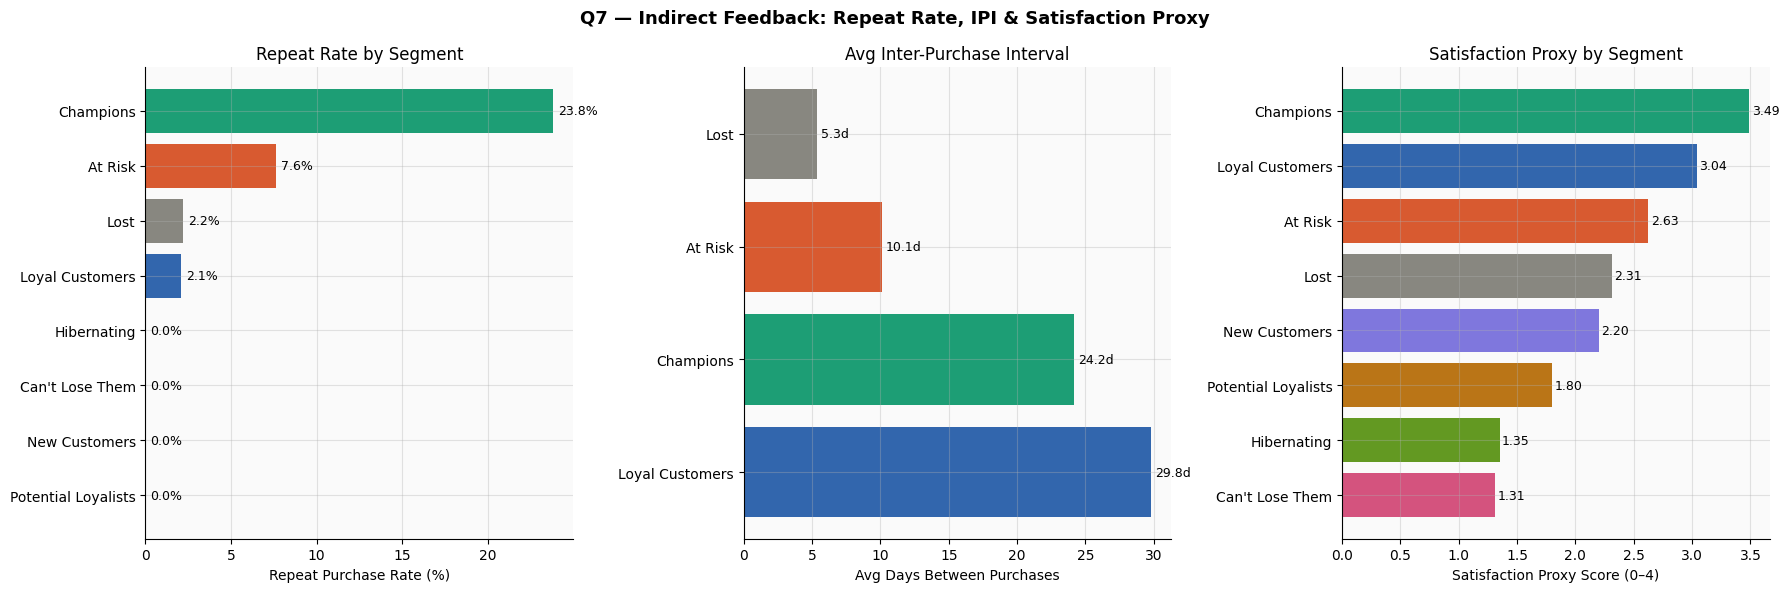

Saved: q7_indirect_feedback.png


In [ ]:
# QUESTION 7 — Indirect Feedback: Repeat Purchases as a Proxy Signal
# Repeat purchase = customer with Frequency > 1
rfm['Is_Repeat']   = (rfm['Frequency'] > 1).astype(int)
rfm['Is_High_Freq'] = (rfm['Frequency'] >= rfm['Frequency'].quantile(0.75)).astype(int)

# Inter-purchase interval (days between consecutive purchases per customer)
df_sorted = df.sort_values(['CustomerID', 'PurchaseDate'])
df_sorted['Prev_Purchase'] = df_sorted.groupby('CustomerID')['PurchaseDate'].shift(1)
df_sorted['Days_Between']  = (df_sorted['PurchaseDate'] - df_sorted['Prev_Purchase']).dt.days

ipi = df_sorted.dropna(subset=['Days_Between']).groupby('CustomerID')['Days_Between'].mean().reset_index()
ipi.columns = ['CustomerID', 'Avg_IPI']

rfm2 = rfm.merge(ipi, on='CustomerID', how='left')

repeat_by_seg = rfm2.groupby('Segment').agg(
    Total_Cust      = ('CustomerID',  'count'),
    Repeat_Cust     = ('Is_Repeat',   'sum'),
    Avg_IPI_days    = ('Avg_IPI',     'mean'),
    Avg_Frequency   = ('Frequency',   'mean')
).round(2)

repeat_by_seg['Repeat_Rate_%'] = (repeat_by_seg['Repeat_Cust'] / repeat_by_seg['Total_Cust'] * 100).round(1)
print("\n--- Repeat Purchase & IPI Analysis by Segment ---")
print(repeat_by_seg.sort_values('Repeat_Rate_%', ascending=False).to_string())

# Satisfaction proxy score (higher repeat + lower IPI = higher satisfaction)
rfm2['Satisfaction_Proxy'] = (rfm2['F_score'] * 0.6 + rfm2['R_score'] * 0.4).round(2)

print("\n--- Satisfaction Proxy Score by Segment ---")
print(rfm2.groupby('Segment')['Satisfaction_Proxy'].mean().round(2)
      .sort_values(ascending=False).to_string())

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Q7 — Indirect Feedback: Repeat Rate, IPI & Satisfaction Proxy', fontsize=13, fontweight='bold')

rr = repeat_by_seg.sort_values('Repeat_Rate_%', ascending=False)
bar_c = [seg_color(s) for s in rr.index]
axes[0].barh(rr.index[::-1], rr['Repeat_Rate_%'][::-1], color=bar_c[::-1])
axes[0].set_xlabel('Repeat Purchase Rate (%)')
axes[0].set_title('Repeat Rate by Segment')
for i, v in enumerate(rr['Repeat_Rate_%'][::-1]):
    axes[0].text(v + 0.3, i, f'{v}%', va='center', fontsize=9)

ipi_data = rr.dropna(subset=['Avg_IPI_days']).sort_values('Avg_IPI_days')
bar_c2 = [seg_color(s) for s in ipi_data.index]
axes[1].barh(ipi_data.index[::-1], ipi_data['Avg_IPI_days'][::-1], color=bar_c2[::-1])
axes[1].set_xlabel('Avg Days Between Purchases')
axes[1].set_title('Avg Inter-Purchase Interval')
for i, v in enumerate(ipi_data['Avg_IPI_days'][::-1]):
    axes[1].text(v + 0.3, i, f'{v:.1f}d', va='center', fontsize=9)

sp = rfm2.groupby('Segment')['Satisfaction_Proxy'].mean().sort_values(ascending=False)
bar_c3 = [seg_color(s) for s in sp.index]
axes[2].barh(sp.index[::-1], sp.values[::-1], color=bar_c3[::-1])
axes[2].set_xlabel('Satisfaction Proxy Score (0–4)')
axes[2].set_title('Satisfaction Proxy by Segment')
for i, v in enumerate(sp.values[::-1]):
    axes[2].text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('q7_indirect_feedback.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: q7_indirect_feedback.png")


--- Total Revenue & Transactions by Day of Week ---
            Revenue  Transactions  Avg_Order
DayOfWeek                                   
Monday     72988.02           146     499.92
Tuesday    67720.21           134     505.37
Wednesday  76735.87           152     504.84
Thursday   72934.36           142     513.62
Friday     73648.30           146     504.44
Saturday   84535.58           152     556.16
Sunday     65115.47           128     508.71

Best revenue day:  Saturday  ($84,535.58)
Worst revenue day: Sunday ($65,115.47)

--- Revenue by Day per Segment ---
Segment     At Risk  Can't Lose Them  Champions  Hibernating      Lost  Loyal Customers  New Customers  Potential Loyalists
DayOfWeek                                                                                                                  
Monday     13617.09          9408.68   15030.13      3567.22   7808.28         15659.80        5271.75              2625.07
Tuesday    17943.22          6055.24   14234.15     

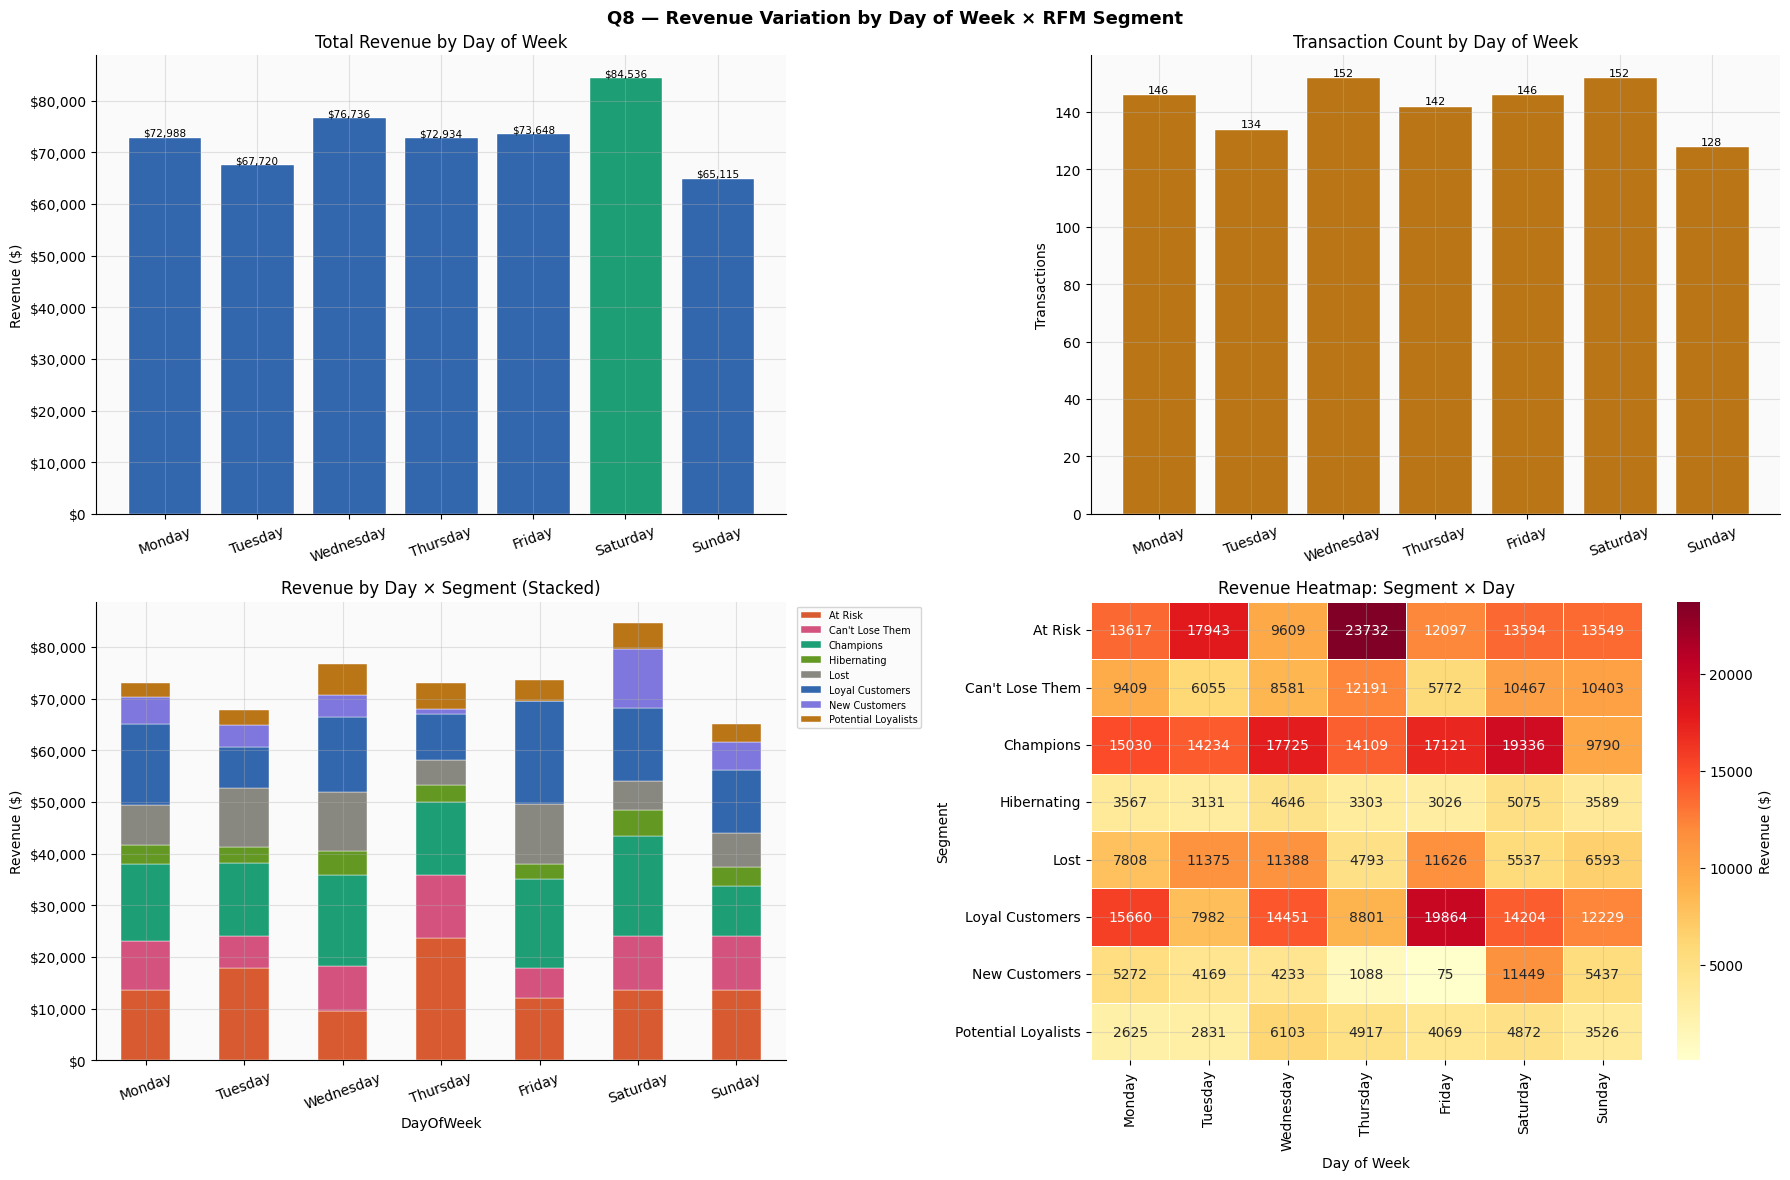

Saved: q8_revenue_by_day.png


In [ ]:
# QUESTION 8 — Revenue Variation by Day of Week per Segment
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df_seg['DayOfWeek'] = df_seg['PurchaseDate'].dt.day_name()

dow_seg = df_seg.groupby(['DayOfWeek', 'Segment']).agg(
    Revenue      = ('TransactionAmount', 'sum'),
    Transactions = ('OrderID',           'count'),
    Avg_Order    = ('TransactionAmount', 'mean')
).reset_index()

dow_seg['DayOfWeek'] = pd.Categorical(dow_seg['DayOfWeek'], categories=day_order, ordered=True)
dow_seg = dow_seg.sort_values('DayOfWeek')

pivot_dow = dow_seg.pivot_table(index='DayOfWeek', columns='Segment',
                                 values='Revenue', aggfunc='sum', fill_value=0)
pivot_dow = pivot_dow.reindex(day_order)

total_dow = df_seg.groupby('DayOfWeek').agg(
    Revenue      = ('TransactionAmount', 'sum'),
    Transactions = ('OrderID',           'count'),
    Avg_Order    = ('TransactionAmount', 'mean')
).reindex(day_order).round(2)

print("\n--- Total Revenue & Transactions by Day of Week ---")
print(total_dow.to_string())

best_day   = total_dow['Revenue'].idxmax()
worst_day  = total_dow['Revenue'].idxmin()
best_rev   = total_dow['Revenue'].max()
worst_rev  = total_dow['Revenue'].min()
print(f"\nBest revenue day:  {best_day}  (${best_rev:,.2f})")
print(f"Worst revenue day: {worst_day} (${worst_rev:,.2f})")

print("\n--- Revenue by Day per Segment ---")
print(pivot_dow.round(2).to_string())

# --- Plot ---
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Q8 — Revenue Variation by Day of Week × RFM Segment', fontsize=13, fontweight='bold')

# 1. Total revenue by day
day_colors = ['#3266ad' if d != best_day else '#1D9E75' for d in day_order]
axes[0,0].bar(total_dow.index,
                    total_dow['Revenue'],
                    color=day_colors, edgecolor='white')
axes[0,0].set_title('Total Revenue by Day of Week')
axes[0,0].set_ylabel('Revenue ($)')
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0,0].tick_params(axis='x', rotation=20)
for i, v in enumerate(total_dow['Revenue']):
    axes[0,0].text(i, v + 200, f'${v:,.0f}', ha='center', fontsize=7.5)

# 2. Transactions by day
axes[0,1].bar(total_dow.index, total_dow['Transactions'], color='#BA7517', edgecolor='white')
axes[0,1].set_title('Transaction Count by Day of Week')
axes[0,1].set_ylabel('Transactions')
axes[0,1].tick_params(axis='x', rotation=20)
for i, v in enumerate(total_dow['Transactions']):
    axes[0,1].text(i, v + 0.5, str(int(v)), ha='center', fontsize=8)

# 3. Stacked bar: segment revenue by day
seg_c = [seg_color(c) for c in pivot_dow.columns]
pivot_dow.plot(kind='bar', stacked=True, ax=axes[1,0],
               color=seg_c, edgecolor='white', linewidth=0.3)
axes[1,0].set_title('Revenue by Day × Segment (Stacked)')
axes[1,0].set_ylabel('Revenue ($)')
axes[1,0].tick_params(axis='x', rotation=20)
axes[1,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1,0].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)

# 4. Heatmap: segment × day
sns.heatmap(pivot_dow.T, annot=True, fmt='.0f', cmap='YlOrRd',
            ax=axes[1,1], linewidths=0.5, cbar_kws={'label': 'Revenue ($)'})
axes[1,1].set_title('Revenue Heatmap: Segment × Day')
axes[1,1].set_xlabel('Day of Week')
axes[1,1].set_ylabel('Segment')

plt.tight_layout()
plt.savefig('q8_revenue_by_day.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: q8_revenue_by_day.png")

<div class="alert alert-success">
Jupyter notebooks are a way to combine executable code, code outputs, and text into one connected file.
</div>

<div class="alert alert-info">
The official documentation from project Jupyter is available
<a href="https://jupyter-notebook.readthedocs.io/en/stable/" class="alert-link">here</a>
and they also have some example notebooks
<a href="https://github.com/jupyter/notebook/tree/master/docs/source/examples/Notebook" class="alert-link">here</a>
.
</div>

## Menu Options & Shortcuts

To get a quick tour of the Jupyter user-interface, click on the 'Help' menu, then click 'User Interface Tour'.

There are also a large number of useful keyboard shortcuts. Click on the 'Help' menu, and then 'Keyboard Shortcuts' to see a list.

## Cells

<div class="alert alert-success">
    The main organizational structure of the notebook are <b> cells </b>.
</div>

**Cells** are an independent 'unit'. When you click into a cell, you can 'run' it by clicking Shift + Enter, or by pressing the play (Run) button at the top of your notebook.

Cells come in different types for writing different things - mainly, text or code.

### Markdown Cells

Cells, can be plain text. In this book, for chapters where code is included, any place you see text - meaning places were we aren'twriting and executing code  - will be written in **Markdown**.

Markdown is a way to specify all the text formatting you see within the text itself.

#### _Italics_ & __Bold__

For example, *italicized text* can be specified with an \_underscore\_ or \*single asterisks\*. So, using markdown formatting, that text would appear as follows:

For example, italicized text can be specified with an _underscore_ or *single asterisks*.

**Bold text** requires \_\_two underccores\_\_ or \*\*two asterisks\*\* surrounding the text you would like to bold. Using Markdown formatting, that text would look like this:

**Bold text** requires __two underccores__ or **two asterisks** surrounding the text you would like to bold.



#### Headers

There are a number of different size header you can use with Markdown formatting. The number of pound signs preceeding the header specifies the size of the header.

For example, the following:

```
# Headers are specified with a pound sign
## The more pound signs, the smaller the header
#### But it's still larger
than just plain text.
```

would appear as follows using Markdown formatting:


## Headers are specified with a pound sign

### The more pound signs, the smaller the header

#### But it's still larger

than just plain text.

---

Note that to specify text for a header. the pound sign is followed by a space before the text for the header. The largest header -- specified by 1 pound sign -- is referred to as an H1 header. The second largest, H2, and so on and so forth.

#### Lists

Finally, **lists** are also possible with Markdown formatting. Ordered lists are specified with a number, followed by a decimal point, followed by a space and then the text for the list. For example, the following:

```
1. numbered item
2. item 2
3. item 3
```

would appear as follows with Markdown formatting:

1. numbered item
2. item 2
3. item 3

Bulleted or unordered lists are also possible. these are specified by either a dash (`-`) or an asterisk (`*`) instead of the number and decimal point.

For example, either of the following:

```
- item 1
- item 2
- item 3
```

or

```
* item 1
* item 2
* item 3
```

would appear as follows with Markdown formatting:

- item 1
- item 2
- item 3

### Code Cells

Markdown is really helpful when you want to share text within a Jupyter notebook; however, you're here to learn to program. So let's start talking about code! Whenever you're writing code, you'll want to be sure the cell is set to be a code cell. Within a Jupyter notebook, whenever a cell is selected, you can look at the menu across the top. The drop-down menu will specify what type of cell you're working with.

Here, we see an example of what you would see for a Markdown cell.

![Markdown cell specified along toolbar](https://github.com/shanellis/pythonbook/blob/master/content/images/01-intro/markdown_cell.png?raw=1)

To change this cell to a code cell, you would select "Code" from the drop-down menu. You'd then be able to write and execute code from the cell!

![Code selected from drop-down menu](https://github.com/shanellis/pythonbook/blob/master/content/images/01-intro/code_cell.png?raw=1)

The next cell is an example of a code cell. The first line in that cell is a **comment**. Comments are ignored by the computer and are there to help humans reading the code understand what's going on. Comments always start with a pound sign. Note that a pound sign in a Markdown cell indicates something different (a header) than it does in a code cell (a comment).

The second and third line in the example below are lines of Python code! Here we're assigning information to two variables: `a` and `b`. We'll talk all about variable assignment in the next chapter.

In [ ]:
# Cell can also be code.
a = 1
b = 2

#### Running Code

What's important to know now is that Jupyter notebooks don't *just* allow you to write code. You can also **execute the code**. Nothing happens until you execute (or "run") code.

For example, in the first cell above, that code was typed but never executed. We know that it wasn't executed because to the left of the cell we see `In [ ]:`.

![Code cell not yet executed](https://github.com/shanellis/pythonbook/blob/master/content/images/01-intro/not_executed.png?raw=1)

The empty brackets suggested that this code has not yet been executed.

Once executed, a number will show up within those brackets:

![Code cell not yet executed](https://github.com/shanellis/pythonbook/blob/master/content/images/01-intro/executed_code.png?raw=1)

The first code cell you run in a Jupyter notebook will have a `[1]`. The second a `[2]` and so on and so forth.

To execute a cell, you can click on the cell you'd like to run and click "Run" along the toolbar at the top. Or, more likely, you'll want to get in the habit of using hte keyboard shortcut `Shift + Enter` to run your cells. note that `Shift + Enter` will run code cells *and* format Markdown cells.

One important caveat is that if you ever see a `[*]`. to to the left of your code cell, this indicates that the cell is still running. This cann happen if you write code that takes a while to run *or* if you've written code that will run forever (such as an infinite loop).

If this happens and you do *not* want to allow the code to continue to execute (for example, you have an infinite loop and want the code to stop from running, you can click on the square stop icon from the toolbar at the top.

![Stop code cell from executing](https://github.com/shanellis/pythonbook/blob/master/content/images/01-intro/stop.png?raw=1)

Upon executing the code in a cell, often, there will be some sort of output. The code below says subtract 2 (the value stored in `b`) from 1 (the value stored in `a`) and store that in the variable `c`. Then, the final line here says, print that value out to the screen.

In [ ]:
# Cells can also have output, that gets printed out below the cell.
c = a - b
print(c)

-1


What you see above is why notebooks are so great! They allow explanatory text, python code, *and* the outputs from that code to intermingle in a single document!

Before we move on, one more piece of information about Jupyter notebooks in particular. If the last line of code in a code cell is a variable name, the Jupyter notebook, will print the contents of that varaible to your screen, without you having to put `print()` around it. We'll use this a bunch throughout the book, so it's worth noting now, even though we haven't *exactly* covered what variables are...yet!

In [ ]:
# if variable last thing in cell
# output will be variable conents
c

-1

#### Cell Order

Ok, so we've discussed that the numbers in the square brackets to the left of a cell show which cells have been run, and in what order and that an asterisk (`*`) means that the cell is currently running. What we haven't yet discussed is that the order in which the cells are run does ***not*** matter to Python or Jupyter notebooks.

This allows you to flexibly test and develop code. For example, say you've run a few cells of code in order from top to bottom. Then, you realize you wanted a different value in that first code cell. You can go back to that first cell, change it to be the value you want, and then return back to a different cell. Python and Jupyter Notebooks will keep track of whatever was run most recently.

For beginners and individuals less familiar with working in notebooks, this can sometimes take a bit to get used to, but the benefits of this flexibility outweigh the cognitive load it takes to remember that the order isn't set in stone to go from top to bottom.

## Accessing Documentation

When you're new to Python (or any programming language), knowing where to look for more information is critical. While Google and StackOverflow will likely be very helpful, Python and Jupyter Notebooks have built-in ways for you to access documentation that will provide you with helpful information.

<div class="alert alert-success">
Jupyter has useful shortcuts. Add a single '?' after a function or class get a window with the documentation, or a double '??' to pull up the source code.
</div>

In [ ]:
# For example, execute this cell to see the documentation for the 'abs'
abs?

## Autocomplete

<div class="alert alert-success">
Jupyter also has
<a href="https://en.wikipedia.org/wiki/Command-line_completion" class="alert-link">tab complete</a>
capacities, which can autocomplete what you are typing, and/or be used to explore what code is available.  
</div>

In [ ]:
# Move your cursor to the end of the line, press tab, and a drop menu will appear showing all possible completions
ra

In [ ]:
# If there is only one option, tab-complete will auto-complete what you are typing
ran

## Web Browser

<div class="alert alert-success">
Jupyter notebooks display in a web browser. They are not hosted on the web, everything is happening locally.
</div>

If you click on the url in the browser, you will notice it says 'localhost'. This means it is connected to something locally, on your computer.

That local connection is to the 'kernel'.

## Kernels

<div class="alert alert-success">
The 'kernel' is the thing that executes your code. It is what connects the notebook (as you see it) with the part of your computer that runs code.
</div>

Your kernel also stores your **namespace** - all the variables and code that you have declared (executed).

It can be useful to clear and re-launch the kernel. You can do this from the 'kernel' drop down menu, at the top, optionally also clearing all ouputs. Note that this will erase any variables that are stored in memory.

<div class="alert alert-info">
For more useful information, check out Jupyter Notebooks
<a href="https://www.dataquest.io/blog/jupyter-notebook-tips-tricks-shortcuts/" class="alert-link">tips & tricks</a>
, and more information on how
<a href="http://jupyter.readthedocs.io/en/latest/architecture/how_jupyter_ipython_work.html" class="alert-link">notebooks work</a>.
</div>

## Exercises

Q1. **What does three underscores around text accomplish?**  

A) bold  
B) italicize  
C) bold + italicize  
D) plain text    


Q2. **Add a cell to a notebook, change it to be a Markdown cell, and add your name as (1) plain text, (2) italicized text, and (3) bold text.**
  

Q3. **What would happen if I specified a numbered list but put the same number before each list item?**  

A) the list would have the same number before each item  
B) markdown would still format it with sequential numbers  
C) markdown wouldn't know it was a list  
D) normal text with everything on a single line  


Q4. **Write code in a code cell and execute it so that the value returned from the cell is '6'.**


Q5. **If the following were in a code cell, what would be the output of the following?**

```python
a = 1
b = 2
c = 3
print(a + b + c)
```
  
Q6. **If the following were in a code cell, what would be the output of the following?**

```python
a = 1
b = 2
c = 3
a + b + c
```
  
Q7. **If the following were in a code cell, what would be the output of the following?**

```python
a = 1
b = 2
c = 3
```